In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [9]:
df.corr(numeric_only= True)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


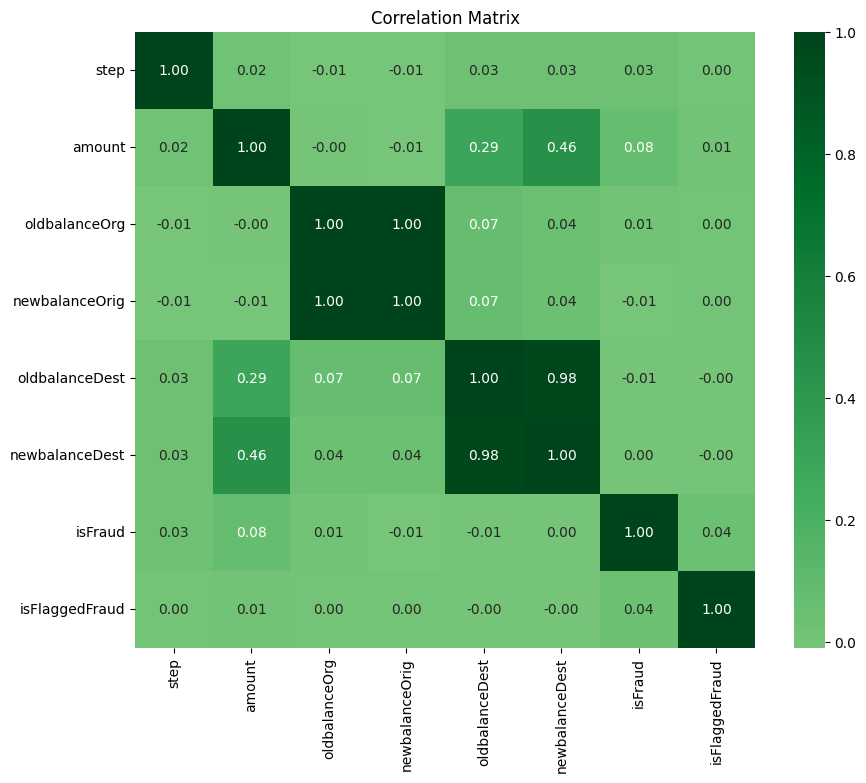

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greens", center=0)
plt.title("Correlation Matrix")
plt.show()

isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


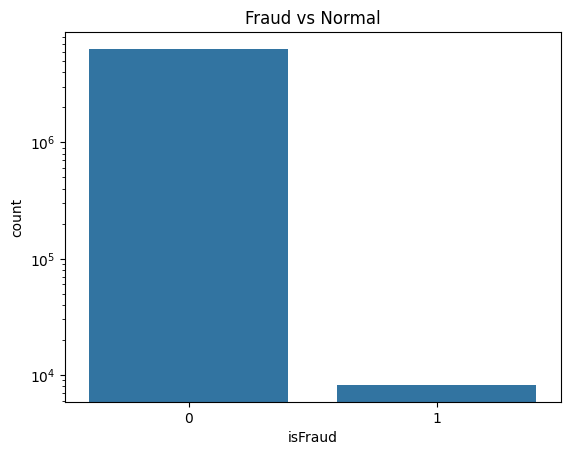

In [11]:
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True) * 100)

sns.countplot(x='isFraud', data=df)
plt.yscale('log')   
plt.title('Fraud vs Normal')
plt.show()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


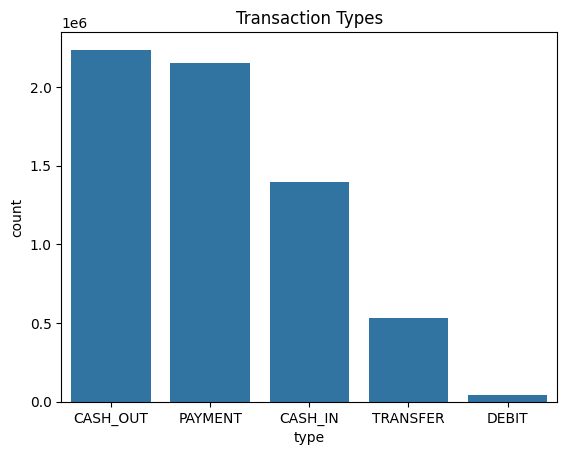

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [12]:
print(df['type'].value_counts())
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title('Transaction Types')
plt.show()

print(df['isFlaggedFraud'].value_counts())

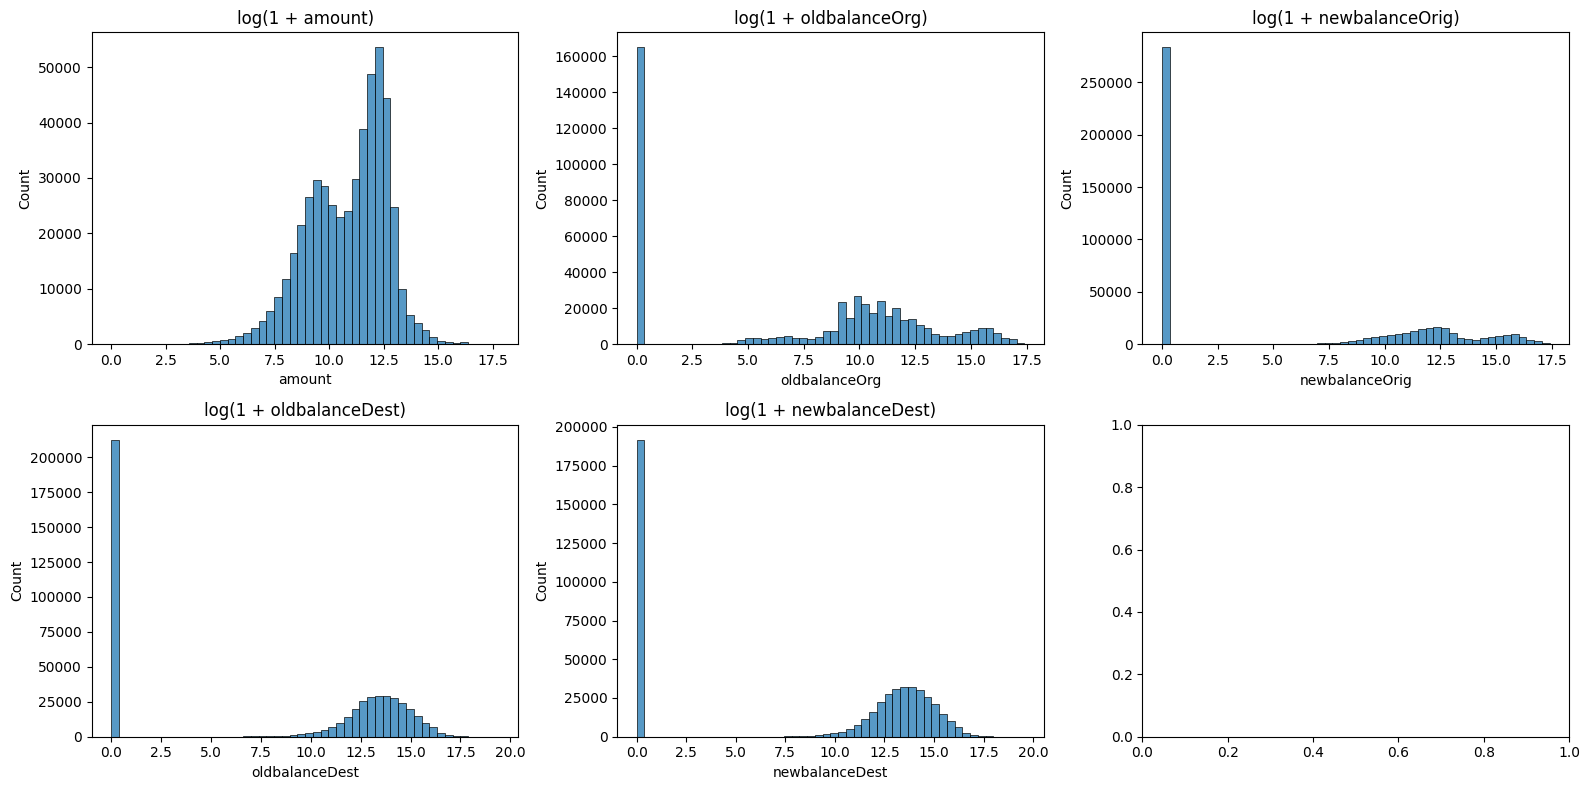

In [13]:
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
sample = df.sample(500000, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(np.log1p(sample[col]), bins=50, ax=ax)
    ax.set_title(f'log(1 + {col})')
plt.tight_layout()
plt.show()

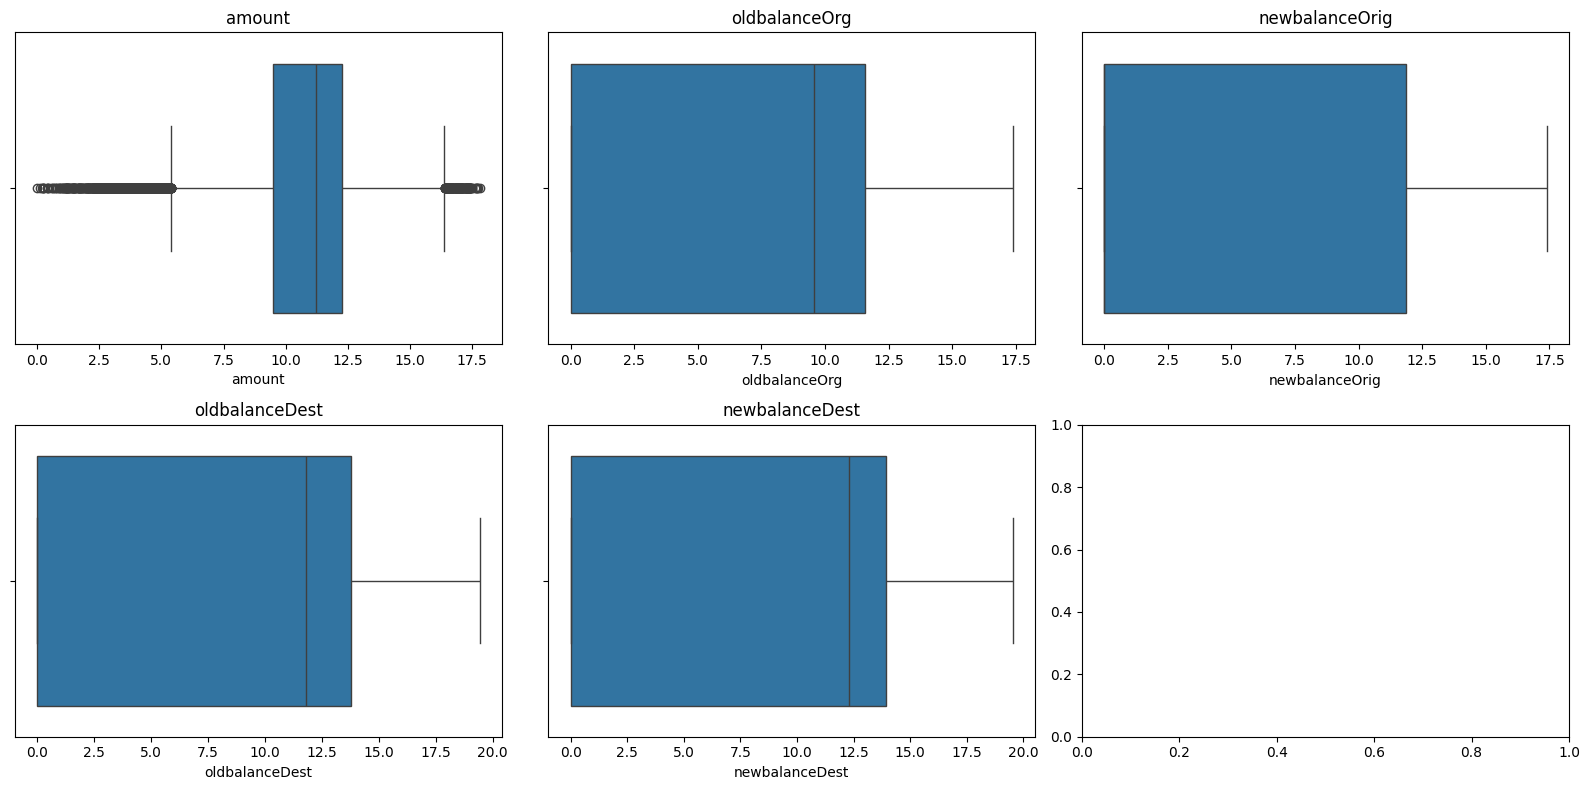

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=np.log1p(sample[col]), ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

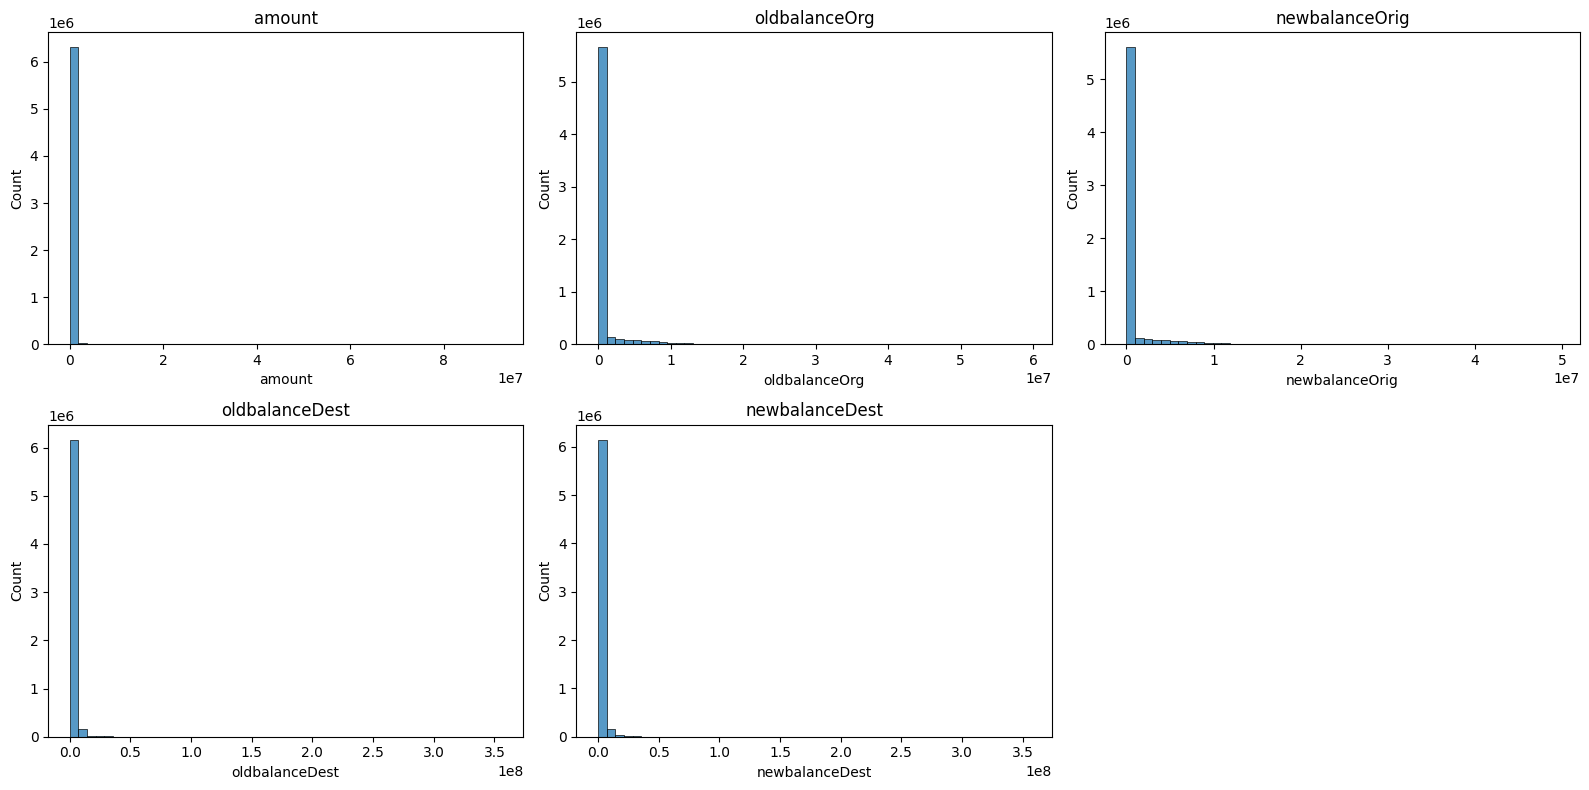

In [15]:
import warnings

warnings.filterwarnings("ignore")

num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=50, ax=ax)
    ax.set_title(col)
axes.flatten()[-1].axis('off')   
plt.tight_layout()
plt.show()

In [16]:
print(df[num_cols].skew())
print((df[num_cols] == 0).mean() * 100) 

amount            30.993949
oldbalanceOrg      5.249136
newbalanceOrig     5.176884
oldbalanceDest    19.921758
newbalanceDest    19.352302
dtype: float64
amount             0.000251
oldbalanceOrg     33.043762
newbalanceOrig    56.730812
oldbalanceDest    42.504314
newbalanceDest    38.340071
dtype: float64


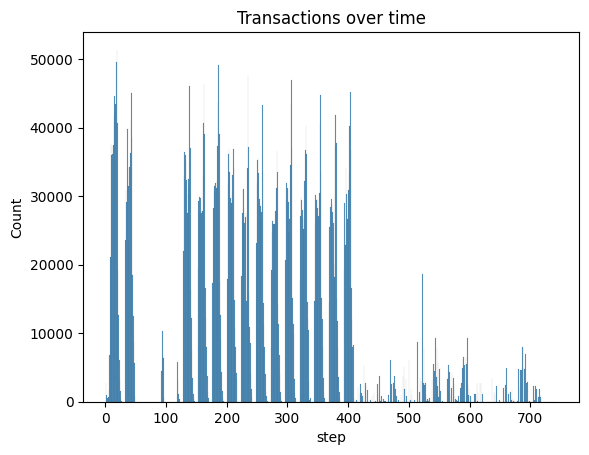

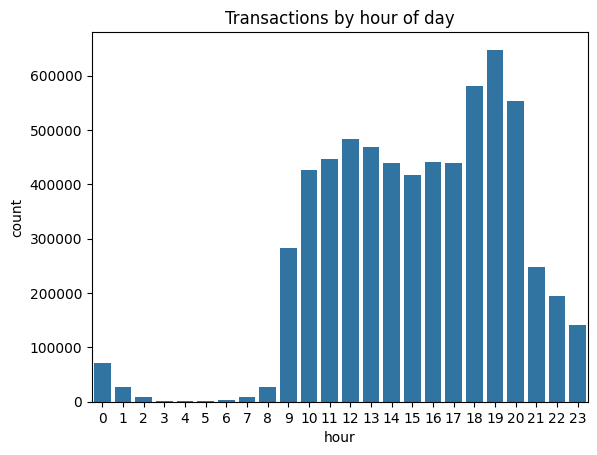

In [17]:
sns.histplot(df['step'], bins=744)
plt.title('Transactions over time')
plt.show()

df['hour'] = df['step'] % 24
sns.countplot(x='hour', data=df)
plt.title('Transactions by hour of day')
plt.show()

In [18]:
print(df['nameOrig'].nunique(), df['nameDest'].nunique())

df['destType'] = df['nameDest'].str[0]   # C ya M
print(df['destType'].value_counts())

6353307 2722362
destType
C    4211125
M    2151495
Name: count, dtype: int64


In [19]:

df[num_cols].describe(percentiles=[.25, .5, .75, .90, .95, .99]).T

(df[num_cols] == 0).mean() * 100

# skewness
df[num_cols].skew()

amount            30.993949
oldbalanceOrg      5.249136
newbalanceOrig     5.176884
oldbalanceDest    19.921758
newbalanceDest    19.352302
dtype: float64

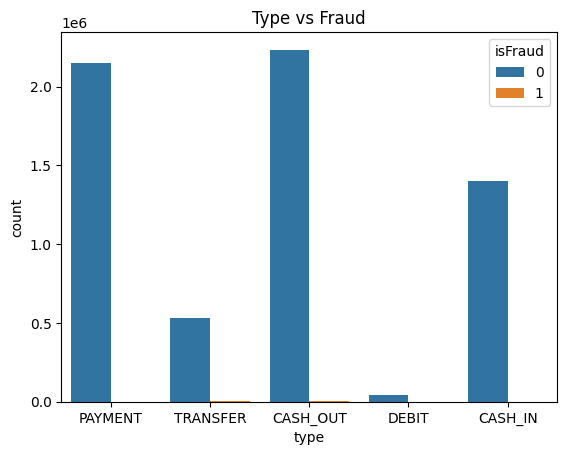

In [20]:
pd.crosstab(df['type'], df['isFraud'])


df.groupby('type')['isFraud'].mean() * 100

sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Type vs Fraud')
plt.show()

In [21]:
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

df.groupby('isFraud')[num_cols].mean().T      # average
df.groupby('isFraud')[num_cols].median().T
df.groupby('isFraud')['amount'].describe()    

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


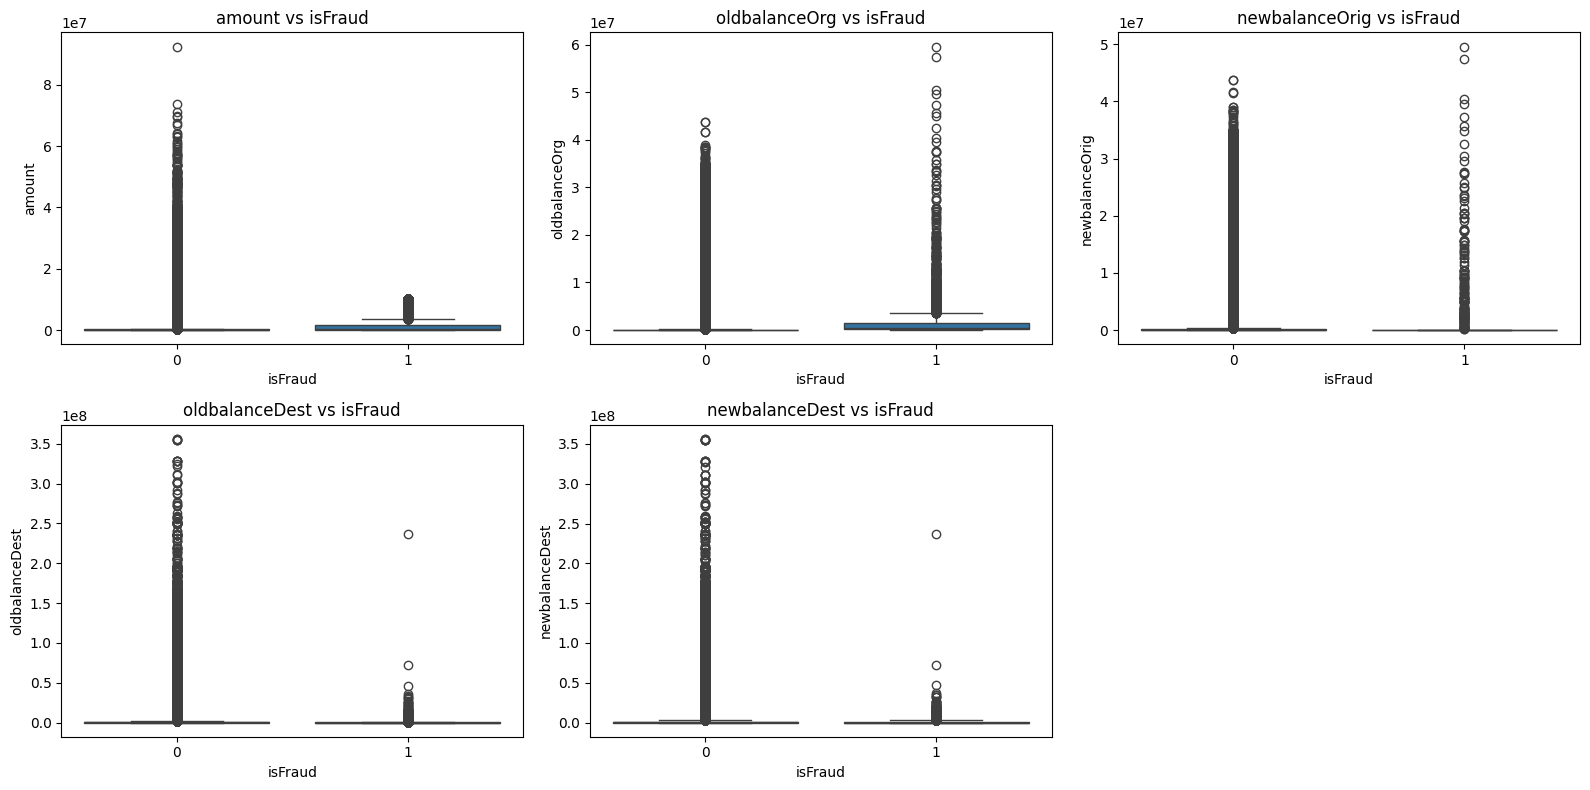

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x='isFraud', y=col, data=df, ax=ax)
    ax.set_title(f'{col} vs isFraud')
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()

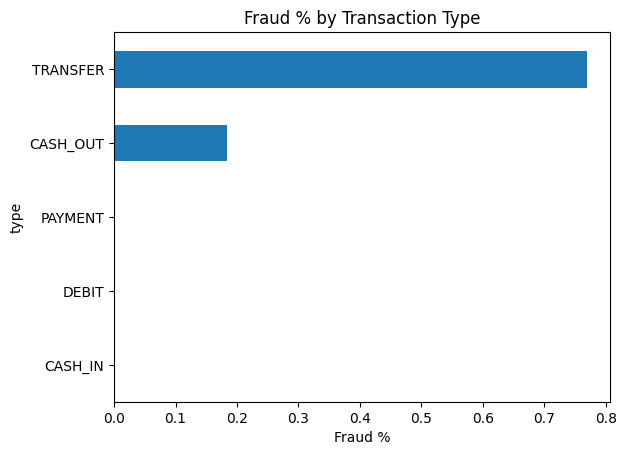

In [23]:
rate = df.groupby('type')['isFraud'].mean() * 100
rate.sort_values().plot(kind='barh', title='Fraud % by Transaction Type')
plt.xlabel('Fraud %')
plt.show()

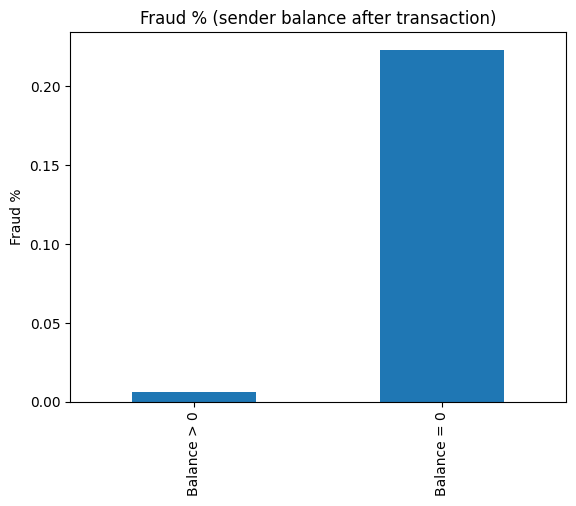

In [24]:
rate = df.groupby(df['newbalanceOrig'] == 0)['isFraud'].mean() * 100
rate.index = ['Balance > 0', 'Balance = 0']
rate.plot(kind='bar', title='Fraud % (sender balance after transaction)')
plt.ylabel('Fraud %')
plt.show()

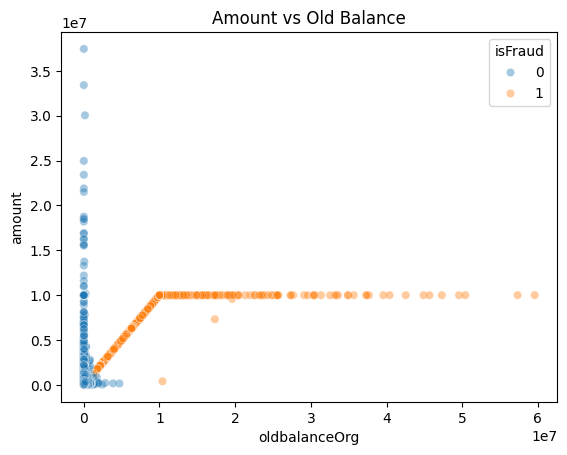

In [25]:
sub = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

fraud = sub[sub['isFraud'] == 1]
normal = sub[sub['isFraud'] == 0].sample(20000, random_state=42)
plot_df = pd.concat([fraud, normal])

sns.scatterplot(x='oldbalanceOrg', y='amount', hue='isFraud', data=plot_df, alpha=0.4)
plt.title('Amount vs Old Balance')
plt.show()

In [26]:
fraud = sub[sub['isFraud'] == 1]
normal = sub[sub['isFraud'] == 0]

print((fraud['amount'] == fraud['oldbalanceOrg']).mean() * 100)   
print(fraud['amount'].max())                                       
print((fraud['oldbalanceOrg'] == 0).sum())                         
print((normal['oldbalanceOrg'] == 0).mean() * 100)                 

97.82052843053695
10000000.0
41
47.37321319703598


In [27]:
data = df.copy()
data.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,destType
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,M
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,M
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,C
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,C
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,M


In [28]:
data = df.copy()

data['errorBalanceOrig'] = data['newbalanceOrig'] + data['amount'] - data['oldbalanceOrg']
data['errorBalanceDest'] = data['oldbalanceDest'] + data['amount'] - data['newbalanceDest']
data['drainedAll'] = (data['amount'] == data['oldbalanceOrg']).astype(int)

data['hour'] = data['step'] % 24
data['destMerchant'] = data['nameDest'].str[0].map({'M': 1, 'C': 0})

data = data.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud', 'step', 'destType'], errors='ignore')
data = pd.get_dummies(data, columns=['type'], dtype=int)

X = data.drop(columns=['isFraud'])
y = data['isFraud']

print(X.shape)
print(X.dtypes)  

(6362620, 15)
amount              float64
oldbalanceOrg       float64
newbalanceOrig      float64
oldbalanceDest      float64
newbalanceDest      float64
hour                  int64
errorBalanceOrig    float64
errorBalanceDest    float64
drainedAll            int64
destMerchant          int64
type_CASH_IN          int64
type_CASH_OUT         int64
type_DEBIT            int64
type_PAYMENT          int64
type_TRANSFER         int64
dtype: object


In [29]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Train fraud %:', y_train.mean() * 100)
print('Test fraud %:', y_test.mean() * 100)
print('Train fraud count:', y_train.sum(), '| Test fraud count:', y_test.sum())

Train: (5090096, 15) | Test: (1272524, 15)
Train fraud %: 0.12907418642005966
Test fraud %: 0.12911347840983745
Train fraud count: 6570 | Test fraud count: 1643


In [30]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score


lr = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000))


lr.fit(X_train, y_train)


y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]


print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))
print('PR-AUC:', average_precision_score(y_test, y_prob))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9715    0.9976    0.9844      1643

    accuracy                         1.0000   1272524
   macro avg     0.9858    0.9988    0.9922   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

[[1270833      48]
 [      4    1639]]
PR-AUC: 0.9976240889196414


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, digits=4))
print(confusion_matrix(y_test, y_pred_rf))
print('PR-AUC:', average_precision_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     1.0000    0.9976    0.9988      1643

    accuracy                         1.0000   1272524
   macro avg     1.0000    0.9988    0.9994   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

[[1270881       0]
 [      4    1639]]
PR-AUC: 0.9986974408817986


In [32]:
missed = X_test[(y_test == 1) & (y_pred_rf == 0)]
print(missed)

           amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
77745   277970.88           0.00             0.0            0.00   
543928   23292.30           0.00             0.0       392364.62   
217978  123194.95       79466.45             0.0       535933.16   
14861   181728.11           0.00             0.0        11397.00   

        newbalanceDest  hour  errorBalanceOrig  errorBalanceDest  drainedAll  \
77745        277970.88    10         277970.88              0.00           0   
543928       415656.92    21          23292.30              0.00           0   
217978       263908.84    13          43728.50         395219.27           0   
14861        184477.77     8         181728.11           8647.34           0   

        destMerchant  type_CASH_IN  type_CASH_OUT  type_DEBIT  type_PAYMENT  \
77745              0             0              1           0             0   
543928             0             0              1           0             0   
217978             0 

In [33]:
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight:', ratio)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    tree_method='hist',
    eval_metric='aucpr',
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, digits=4))
print(confusion_matrix(y_test, y_pred_xgb))
print('PR-AUC:', average_precision_score(y_test, y_prob_xgb))

scale_pos_weight: 773.7482496194825
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9964    0.9976    0.9970      1643

    accuracy                         1.0000   1272524
   macro avg     0.9982    0.9988    0.9985   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

[[1270875       6]
 [      4    1639]]
PR-AUC: 0.9980134644553166


In [34]:
risky = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])
           & (df['oldbalanceOrg'] == 0)
           & (df['newbalanceOrig'] == 0)
           & (df['amount'] > 0)]
print(risky['isFraud'].value_counts())

isFraud
0    1308541
1         25
Name: count, dtype: int64


In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [precision_score(y_test, y_pred),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred),
               recall_score(y_test, y_pred_rf),
               recall_score(y_test, y_pred_xgb)],
    'F1': [f1_score(y_test, y_pred),
           f1_score(y_test, y_pred_rf),
           f1_score(y_test, y_pred_xgb)],
    'PR-AUC': [average_precision_score(y_test, y_prob),
               average_precision_score(y_test, y_prob_rf),
               average_precision_score(y_test, y_prob_xgb)],
})
results.round(4)

,Model,Precision,Recall,F1,PR-AUC
0,Logistic Regression,0.9715,0.9976,0.9844,0.9976
1,Random Forest,1.0000,0.9976,0.9988,0.9987
2,XGBoost,0.9964,0.9976,0.9970,0.9980


In [36]:
import matplotlib.pyplot as plt

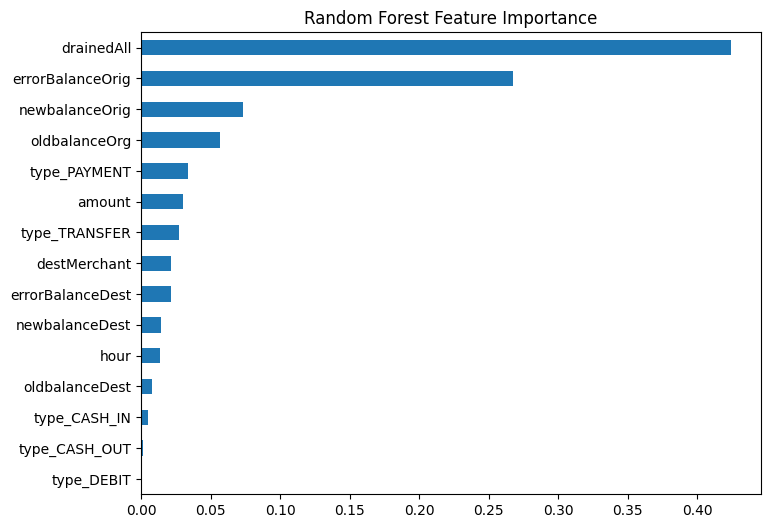

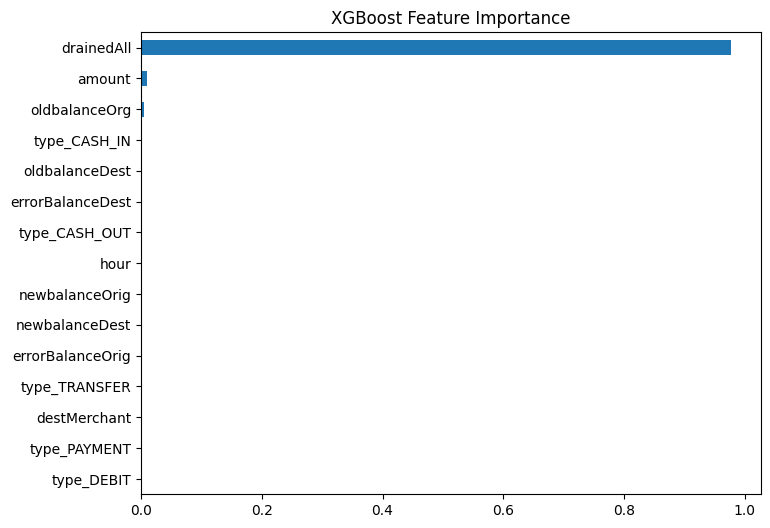

In [37]:
imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp_rf.plot(kind='barh', figsize=(8, 6), title='Random Forest Feature Importance')
plt.show()

imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()
imp_xgb.plot(kind='barh', figsize=(8, 6), title='XGBoost Feature Importance')
plt.show()

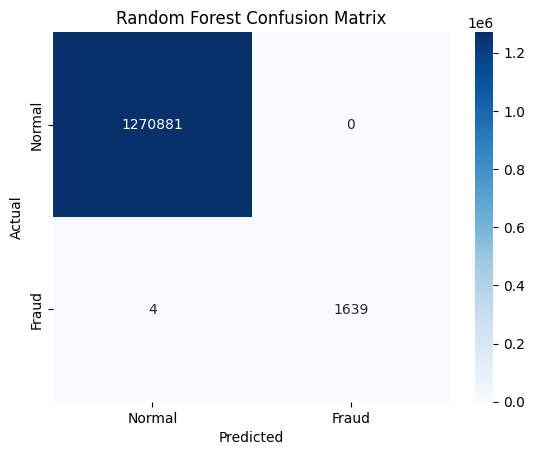

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [39]:

amount = 181000
oldbalanceOrg = 181000
newbalanceOrig = 0
oldbalanceDest = 0
newbalanceDest = 0
txn_type = 'TRANSFER'     
hour = 3                  
destMerchant = 0          

new = pd.DataFrame([{
    'amount': amount,
    'oldbalanceOrg': oldbalanceOrg,
    'newbalanceOrig': newbalanceOrig,
    'oldbalanceDest': oldbalanceDest,
    'newbalanceDest': newbalanceDest,
    'errorBalanceOrig': newbalanceOrig + amount - oldbalanceOrg,
    'errorBalanceDest': oldbalanceDest + amount - newbalanceDest,
    'drainedAll': int(amount == oldbalanceOrg),
    'hour': hour,
    'destMerchant': destMerchant,
    'type_CASH_IN': int(txn_type == 'CASH_IN'),
    'type_CASH_OUT': int(txn_type == 'CASH_OUT'),
    'type_DEBIT': int(txn_type == 'DEBIT'),
    'type_PAYMENT': int(txn_type == 'PAYMENT'),
    'type_TRANSFER': int(txn_type == 'TRANSFER'),
}])

new = new[X.columns]   

prob = rf.predict_proba(new)[0, 1]
print('Fraud probability:', round(prob, 4))
print('Result:', 'FRAUD' if prob >= 0.5 else 'NORMAL')

Fraud probability: 1.0
Result: FRAUD


In [40]:

xgb.save_model('fraud_model.json')
print(list(X.columns))

['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'hour', 'errorBalanceOrig', 'errorBalanceDest', 'drainedAll', 'destMerchant', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [41]:
import os
print(os.listdir('/kaggle/working'))
print(os.path.getsize('/kaggle/working/fraud_model.json') / 1024, 'KB')

['fraud_model.json', '__notebook__.ipynb']
754.6748046875 KB


In [42]:
import joblib, os, sklearn

joblib.dump(rf, 'rf_model.joblib', compress=3)
print(os.path.getsize('rf_model.joblib') / 1024 / 1024, 'MB')
print(sklearn.__version__)

0.2208242416381836 MB
1.6.1


In [43]:
import zipfile

with zipfile.ZipFile('rf_model.zip', 'w') as z:
    z.write('rf_model.joblib')

In [44]:
print(list(rf.feature_names_in_))

['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'hour', 'errorBalanceOrig', 'errorBalanceDest', 'drainedAll', 'destMerchant', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
